In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.optimize import linprog, linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
warnings.simplefilter("ignore")

In [2]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [3]:
DEBUG = True

In [4]:
model_keys = [
    "ideal",
    "content_5",
    "content_10",
    "pop",
    "mf",
    "sf",
    "random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rs_feed",
    "rand_feed",
    "pop_feed",
    "trend_feed",
    "new_feed",
    "social_feed",
    ]

In [5]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

rs_colors = {
    'ideal' : 'tab:blue',
    'content_5' : 'darkgreen',
    'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'chocolate',
    'mf' : 'tab:purple',
    'random' : 'tab:pink',
}

feed_colors = {
    "rs_feed": "grey",
    "rand_feed": "magenta",
    "pop_feed": "darkred",
    "trend_feed": "orange",
    "new_feed": "purple",
    "social_feed": "saddlebrown",
}
indexable_feed_colors = np.array(list(feed_colors.values()))

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content Filtering 5 Tags",
    "content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

feed_names_to_readable = {
    "rs_feed": "RS Feed",
    "rand_feed": "Random Feed",
    "pop_feed": "Pop Feed",
    "trend_feed": "Trend Feed",
    "new_feed": "News Feed",
    "social_feed": "Social Feed",
    "ideal_feed": "Ideal Feed",
}

In [6]:
folder_paths = ["/home/salveal/data/salveal/results18"]
inpi = 40

In [7]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [8]:
interactions = dict()
for mo in model_to_readable.keys():
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [9]:
decisions = dict()
for mo in model_to_readable.keys():
    decisions[mo] = np.array(final_results['decisions'][mo])
    decisions[mo] = np.transpose(decisions[mo], axes=[0,2,1])

In [10]:
utilities = dict()
for mo in model_to_readable.keys():
    utilities[mo] = np.array(final_results['utility_history'][mo])
    utilities[mo] = np.transpose(utilities[mo], axes=[0,2,1])

In [11]:
traits = dict()
for mo in model_to_readable.keys():
    traits[mo] = np.array(final_results['trait_history'][mo])
    traits[mo] = np.transpose(traits[mo], axes=[0,2,1,3])

In [12]:
ranks = dict()
for mo in model_to_readable.keys():
    ranks[mo] = np.array(final_results['rank_history'][mo])
    ranks[mo] = np.transpose(ranks[mo], axes=[0,2,1])

In [13]:
util_ranks = dict()
for mo in model_to_readable.keys():
    util_ranks[mo] = np.array(final_results['utility_rank_history'][mo])
    util_ranks[mo] = np.transpose(util_ranks[mo], axes=[0,2,1])

In [14]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import davies_bouldin_score

In [15]:
folder_paths_base = ["/home/salveal/data/salveal/results17/rand_feed/r0"]
inpi = 40

In [16]:
final_base_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths_base:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_base_results[metric_name][model_name] += np.array(metric_vals).tolist()
user_prefs = np.array(final_base_results['user_prefs']['all'])
item_attrs = np.array(final_base_results['item_attrs']['all'])

In [17]:
base_utilities = dict()
for mo in model_to_readable.keys():
    base_utilities[mo] = np.array(final_base_results['utility_history'][mo])
    base_utilities[mo] = np.transpose(base_utilities[mo], axes=[0,2,1])

In [18]:
base_utilities["content_5"].shape
utilities["content_5"].mean()

0.2444132606636285

## Distribución de Feeds

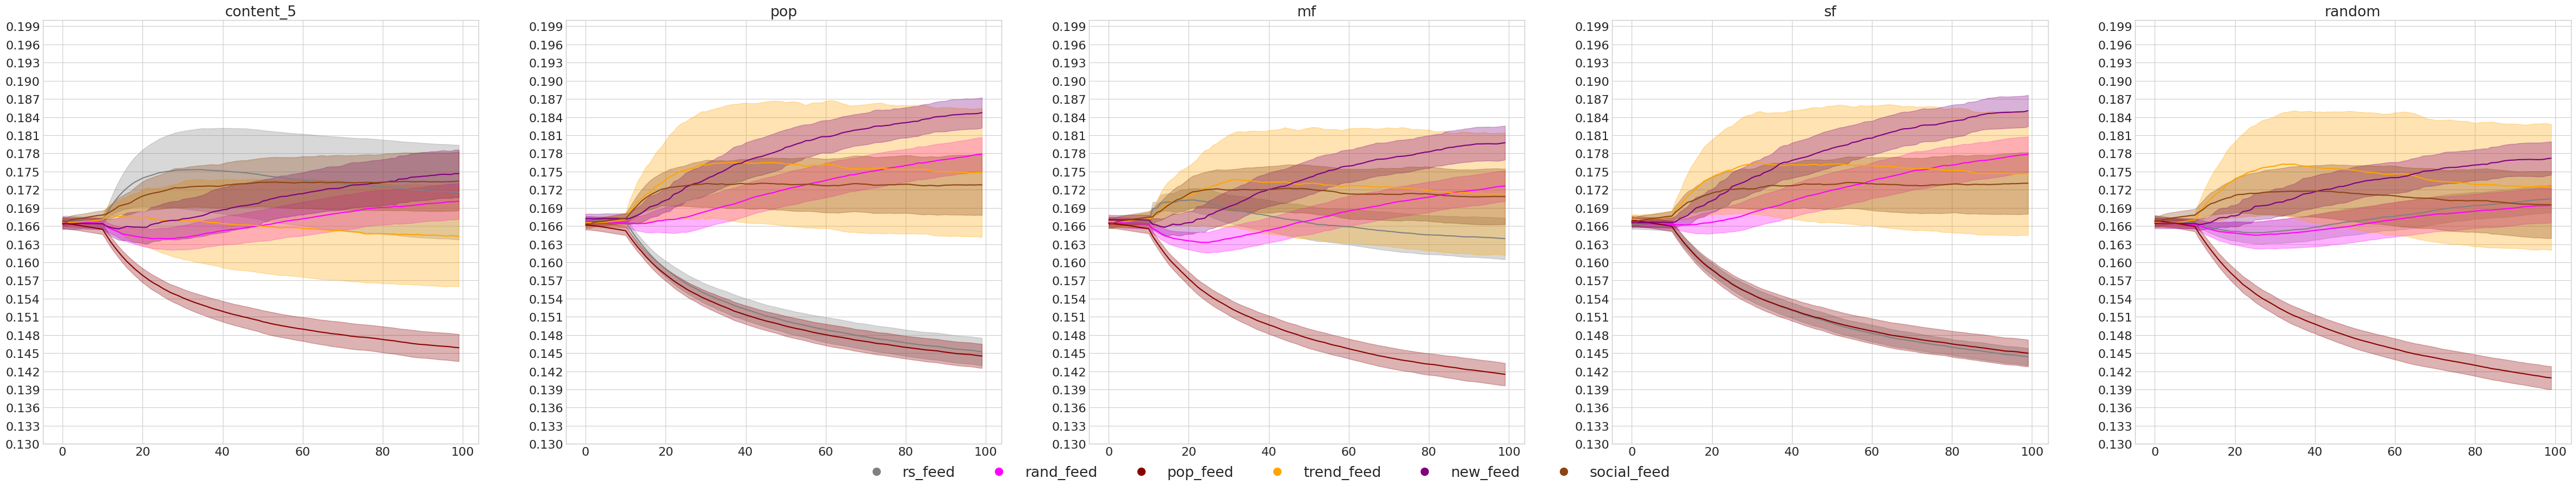

In [19]:
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 5, figsize=(60, 10))  # 1 rows, 5 columns, 60 width x 10 height
fig.subplots_adjust(hspace=0.2, wspace=0.2, bottom=0.1)

col=-1
upper_ylim = -10.0
lower_ylim = 10.0
off_model_keys = [model_keys[1]] + model_keys[3:]

feed_legend_handles = []
feed_legend_labels = []
rs_legend_handles = []
rs_legend_labels = []

for mo in off_model_keys:
    #feed_colors["rs_feed"] = rs_colors[mo]
    #indexable_feed_colors[0] = rs_colors[mo]
    col += 1
    for feed_i in range(len(feed_names)):
        ax = axes[col]
        y_axis = traits[mo][:,:,:,feed_i].mean(axis=1)
        line = ax.plot(y_axis.mean(axis=0), label=feed_names[feed_i], color=feed_colors[feed_names[feed_i]])
        
        feed_legend_handles.append(line[0])
        feed_legend_labels.append(feed_names[feed_i])

        std = y_axis.std(axis=0)
        mtus = np.arange(len(std))
        low = y_axis.mean(axis=0) - 0.5 * std
        high = y_axis.mean(axis=0) + 0.5 * std
        low = gaussian_filter1d(low, sigma=0.1)
        high = gaussian_filter1d(high, sigma=0.1)
        ax.fill_between(mtus, low, high, color=feed_colors[feed_names[feed_i]], alpha=0.3)

        upper_ylim = max(high.max(), upper_ylim)
        lower_ylim = min(low.min(), lower_ylim)

upper_ylim = np.round(upper_ylim, 2) + 0.01
lower_ylim = np.round(lower_ylim, 2) - 0.01

for ax, col in zip(axes, off_model_keys):
    ax.set_title(col)
    ax.set_ylim((lower_ylim, upper_ylim))
    ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 3)))

colors = indexable_feed_colors
labels = feed_legend_labels

legend_handles = [Line2D([0], [0],
                        marker='o',
                        color=c,
                        label=l,
                        markersize=10,
                        linestyle='None')
                 for c, l in zip(colors, labels)]

# Add the legend at the bottom of the figure
fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, 0.01),  # Adjust y position as needed
           ncol=len(off_model_keys) + len(feed_names),  # Number of columns in legend
           fontsize='large')  # Adjust font size as needed

plt.show()

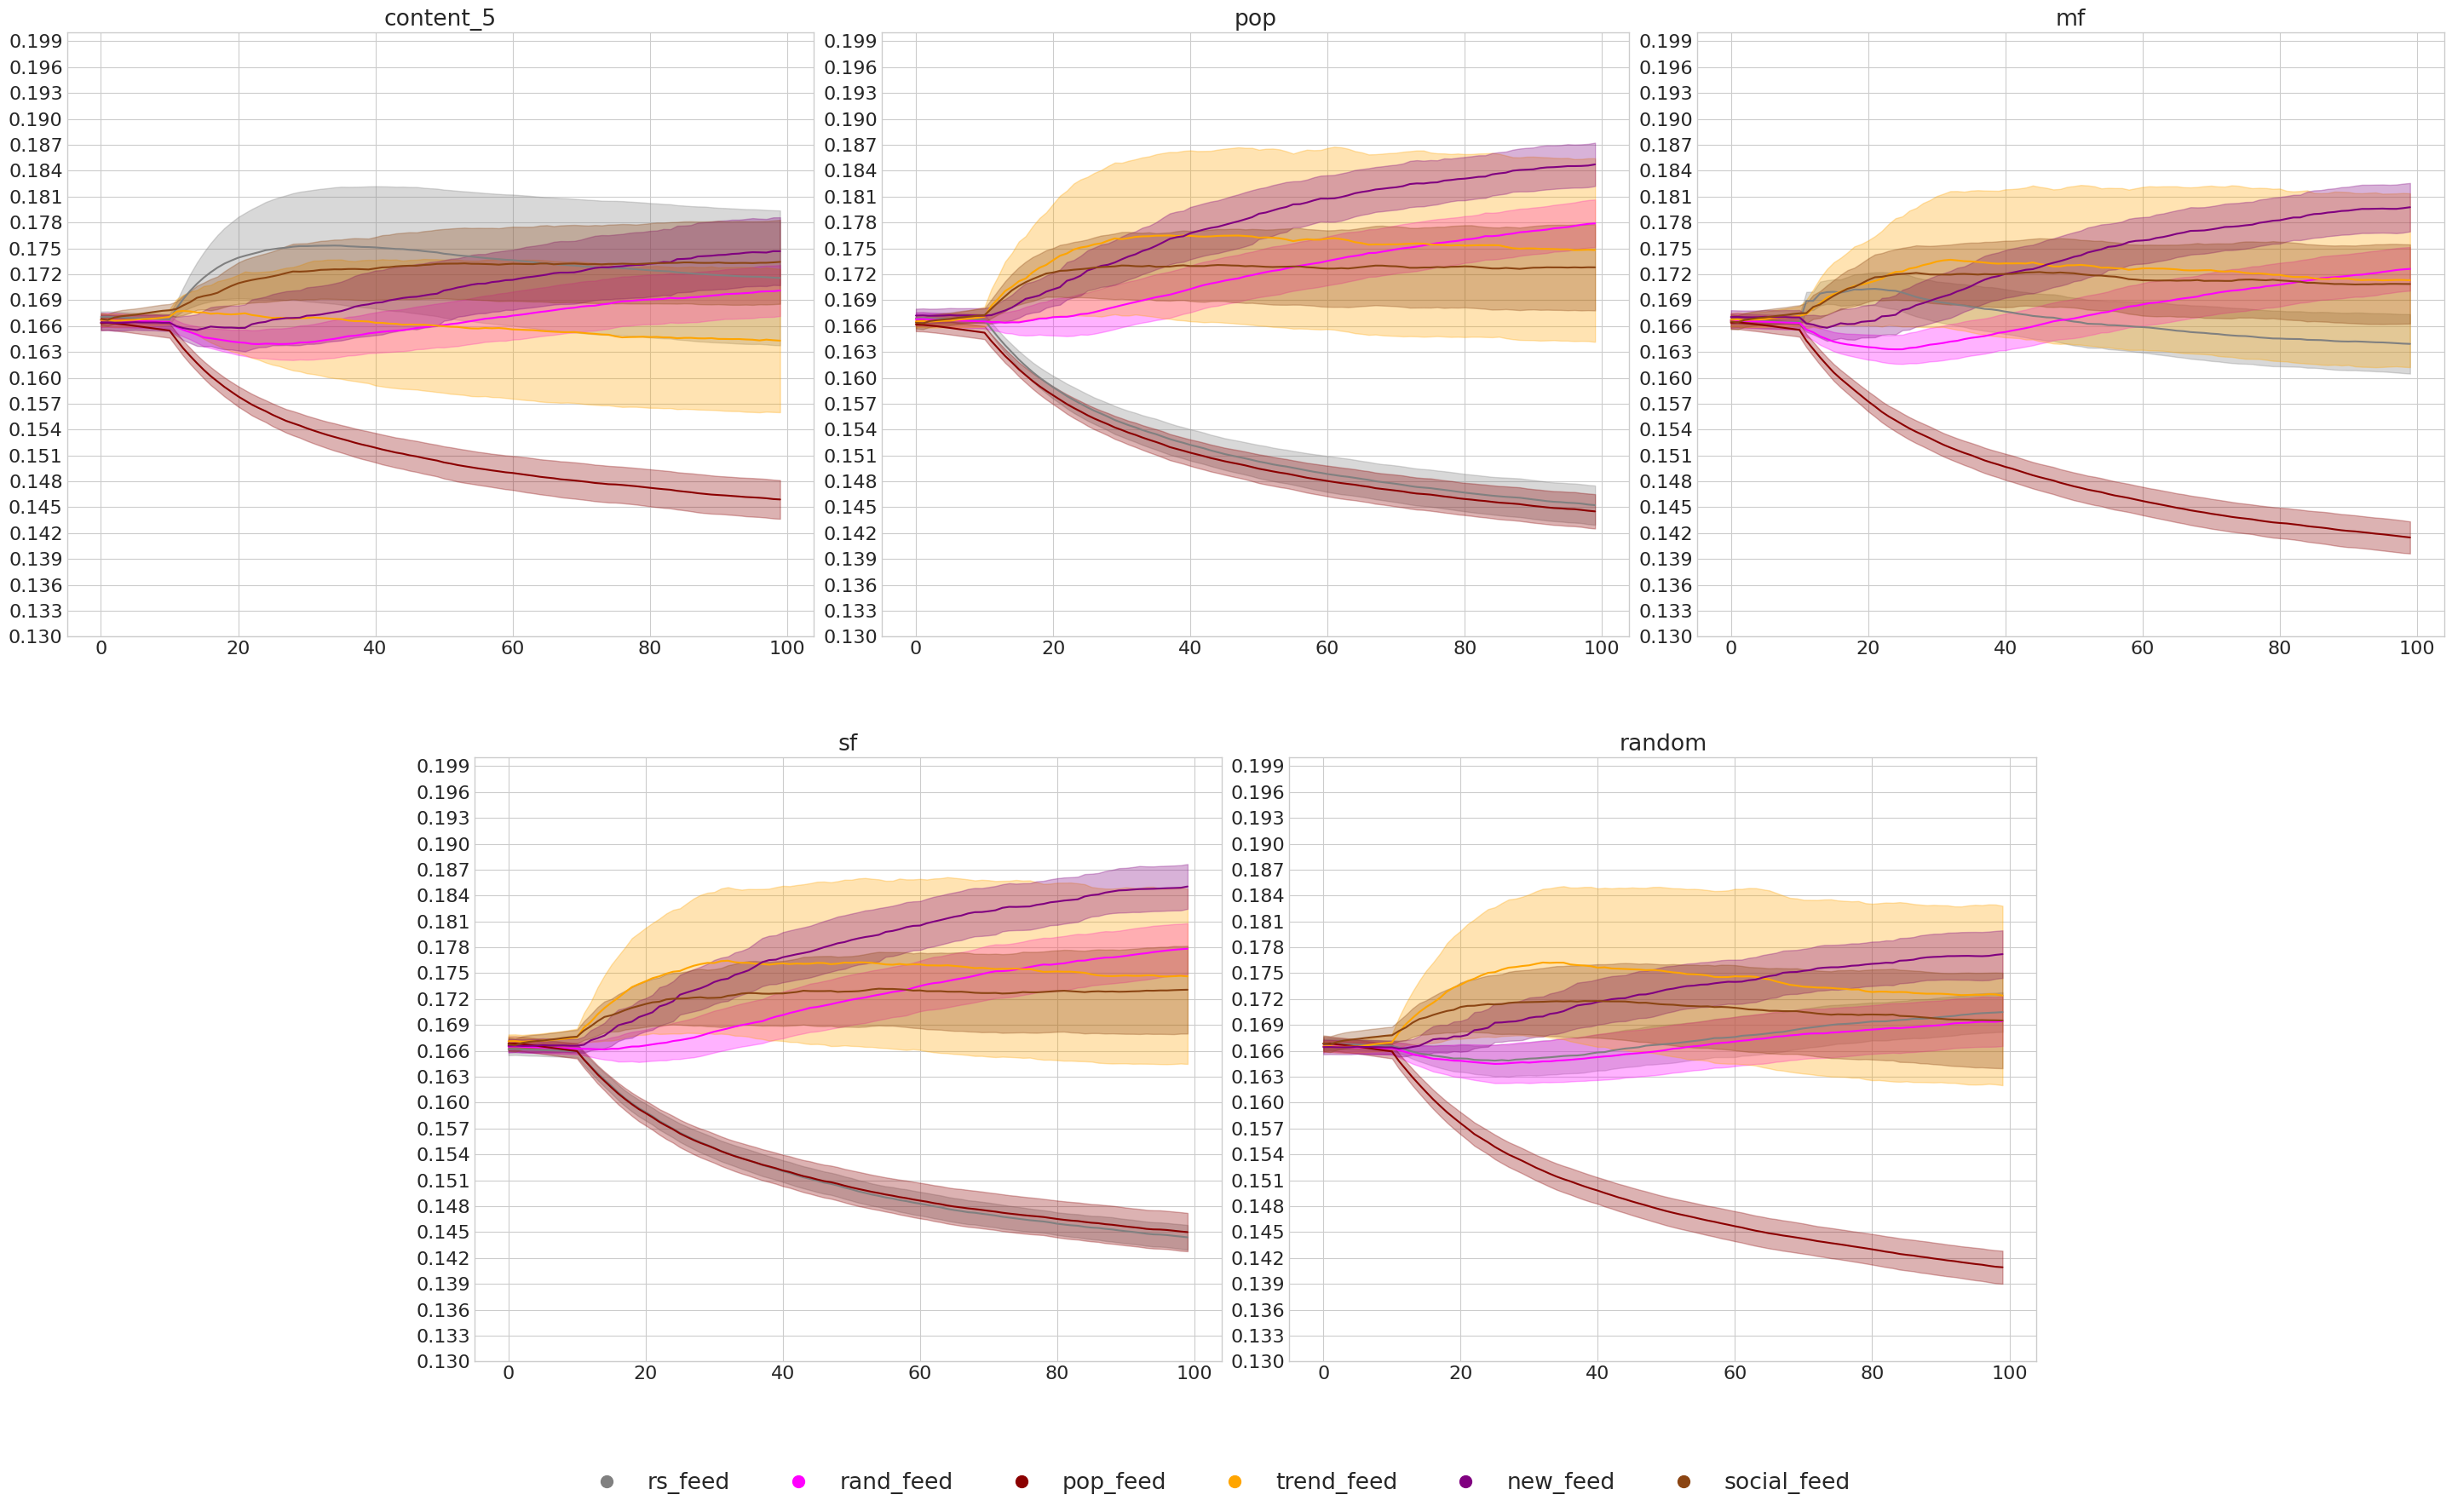

In [20]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(36, 20))
fig.subplots_adjust(hspace=0.2, wspace=0.2, bottom=0.1)
gs = gridspec.GridSpec(2, 6)

col=-1
upper_ylim = -10.0
lower_ylim = 10.0
off_model_keys = [model_keys[1]] + model_keys[3:]

feed_legend_handles = []
feed_legend_labels = []
rs_legend_handles = []
rs_legend_labels = []

axes = []
axes.append(gs[0,0:2])
axes.append(gs[0,2:4])
axes.append(gs[0,4:6])
axes.append(gs[1,1:3])
axes.append(gs[1,3:5])

for mo in off_model_keys:
    #feed_colors["rs_feed"] = rs_colors[mo]
    #indexable_feed_colors[0] = rs_colors[mo]
    col += 1
    for feed_i in range(len(feed_names)):
        ax = plt.subplot(axes[col])
        y_axis = traits[mo][:,:,:,feed_i].mean(axis=1)
        line = ax.plot(y_axis.mean(axis=0), label=feed_names[feed_i], color=feed_colors[feed_names[feed_i]])
        
        feed_legend_handles.append(line[0])
        feed_legend_labels.append(feed_names[feed_i])

        std = y_axis.std(axis=0)
        mtus = np.arange(len(std))
        low = y_axis.mean(axis=0) - 0.5 * std
        high = y_axis.mean(axis=0) + 0.5 * std
        low = gaussian_filter1d(low, sigma=0.1)
        high = gaussian_filter1d(high, sigma=0.1)
        ax.fill_between(mtus, low, high, color=feed_colors[feed_names[feed_i]], alpha=0.3)

        upper_ylim = max(high.max(), upper_ylim)
        lower_ylim = min(low.min(), lower_ylim)

upper_ylim = np.round(upper_ylim, 2) + 0.01
lower_ylim = np.round(lower_ylim, 2) - 0.01

for p, col in zip(axes, off_model_keys):
    ax = plt.subplot(p)
    ax.set_title(col)
    ax.set_ylim((lower_ylim, upper_ylim))
    ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 3)))

colors = indexable_feed_colors
labels = feed_legend_labels

legend_handles = [Line2D([0], [0],
                        marker='o',
                        color=c,
                        label=l,
                        markersize=10,
                        linestyle='None')
                 for c, l in zip(colors, labels)]

# Add the legend at the bottom of the figure
fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, 0.01),  # Adjust y position as needed
           ncol=len(off_model_keys) + len(feed_names),  # Number of columns in legend
           fontsize='large')  # Adjust font size as needed

plt.show()

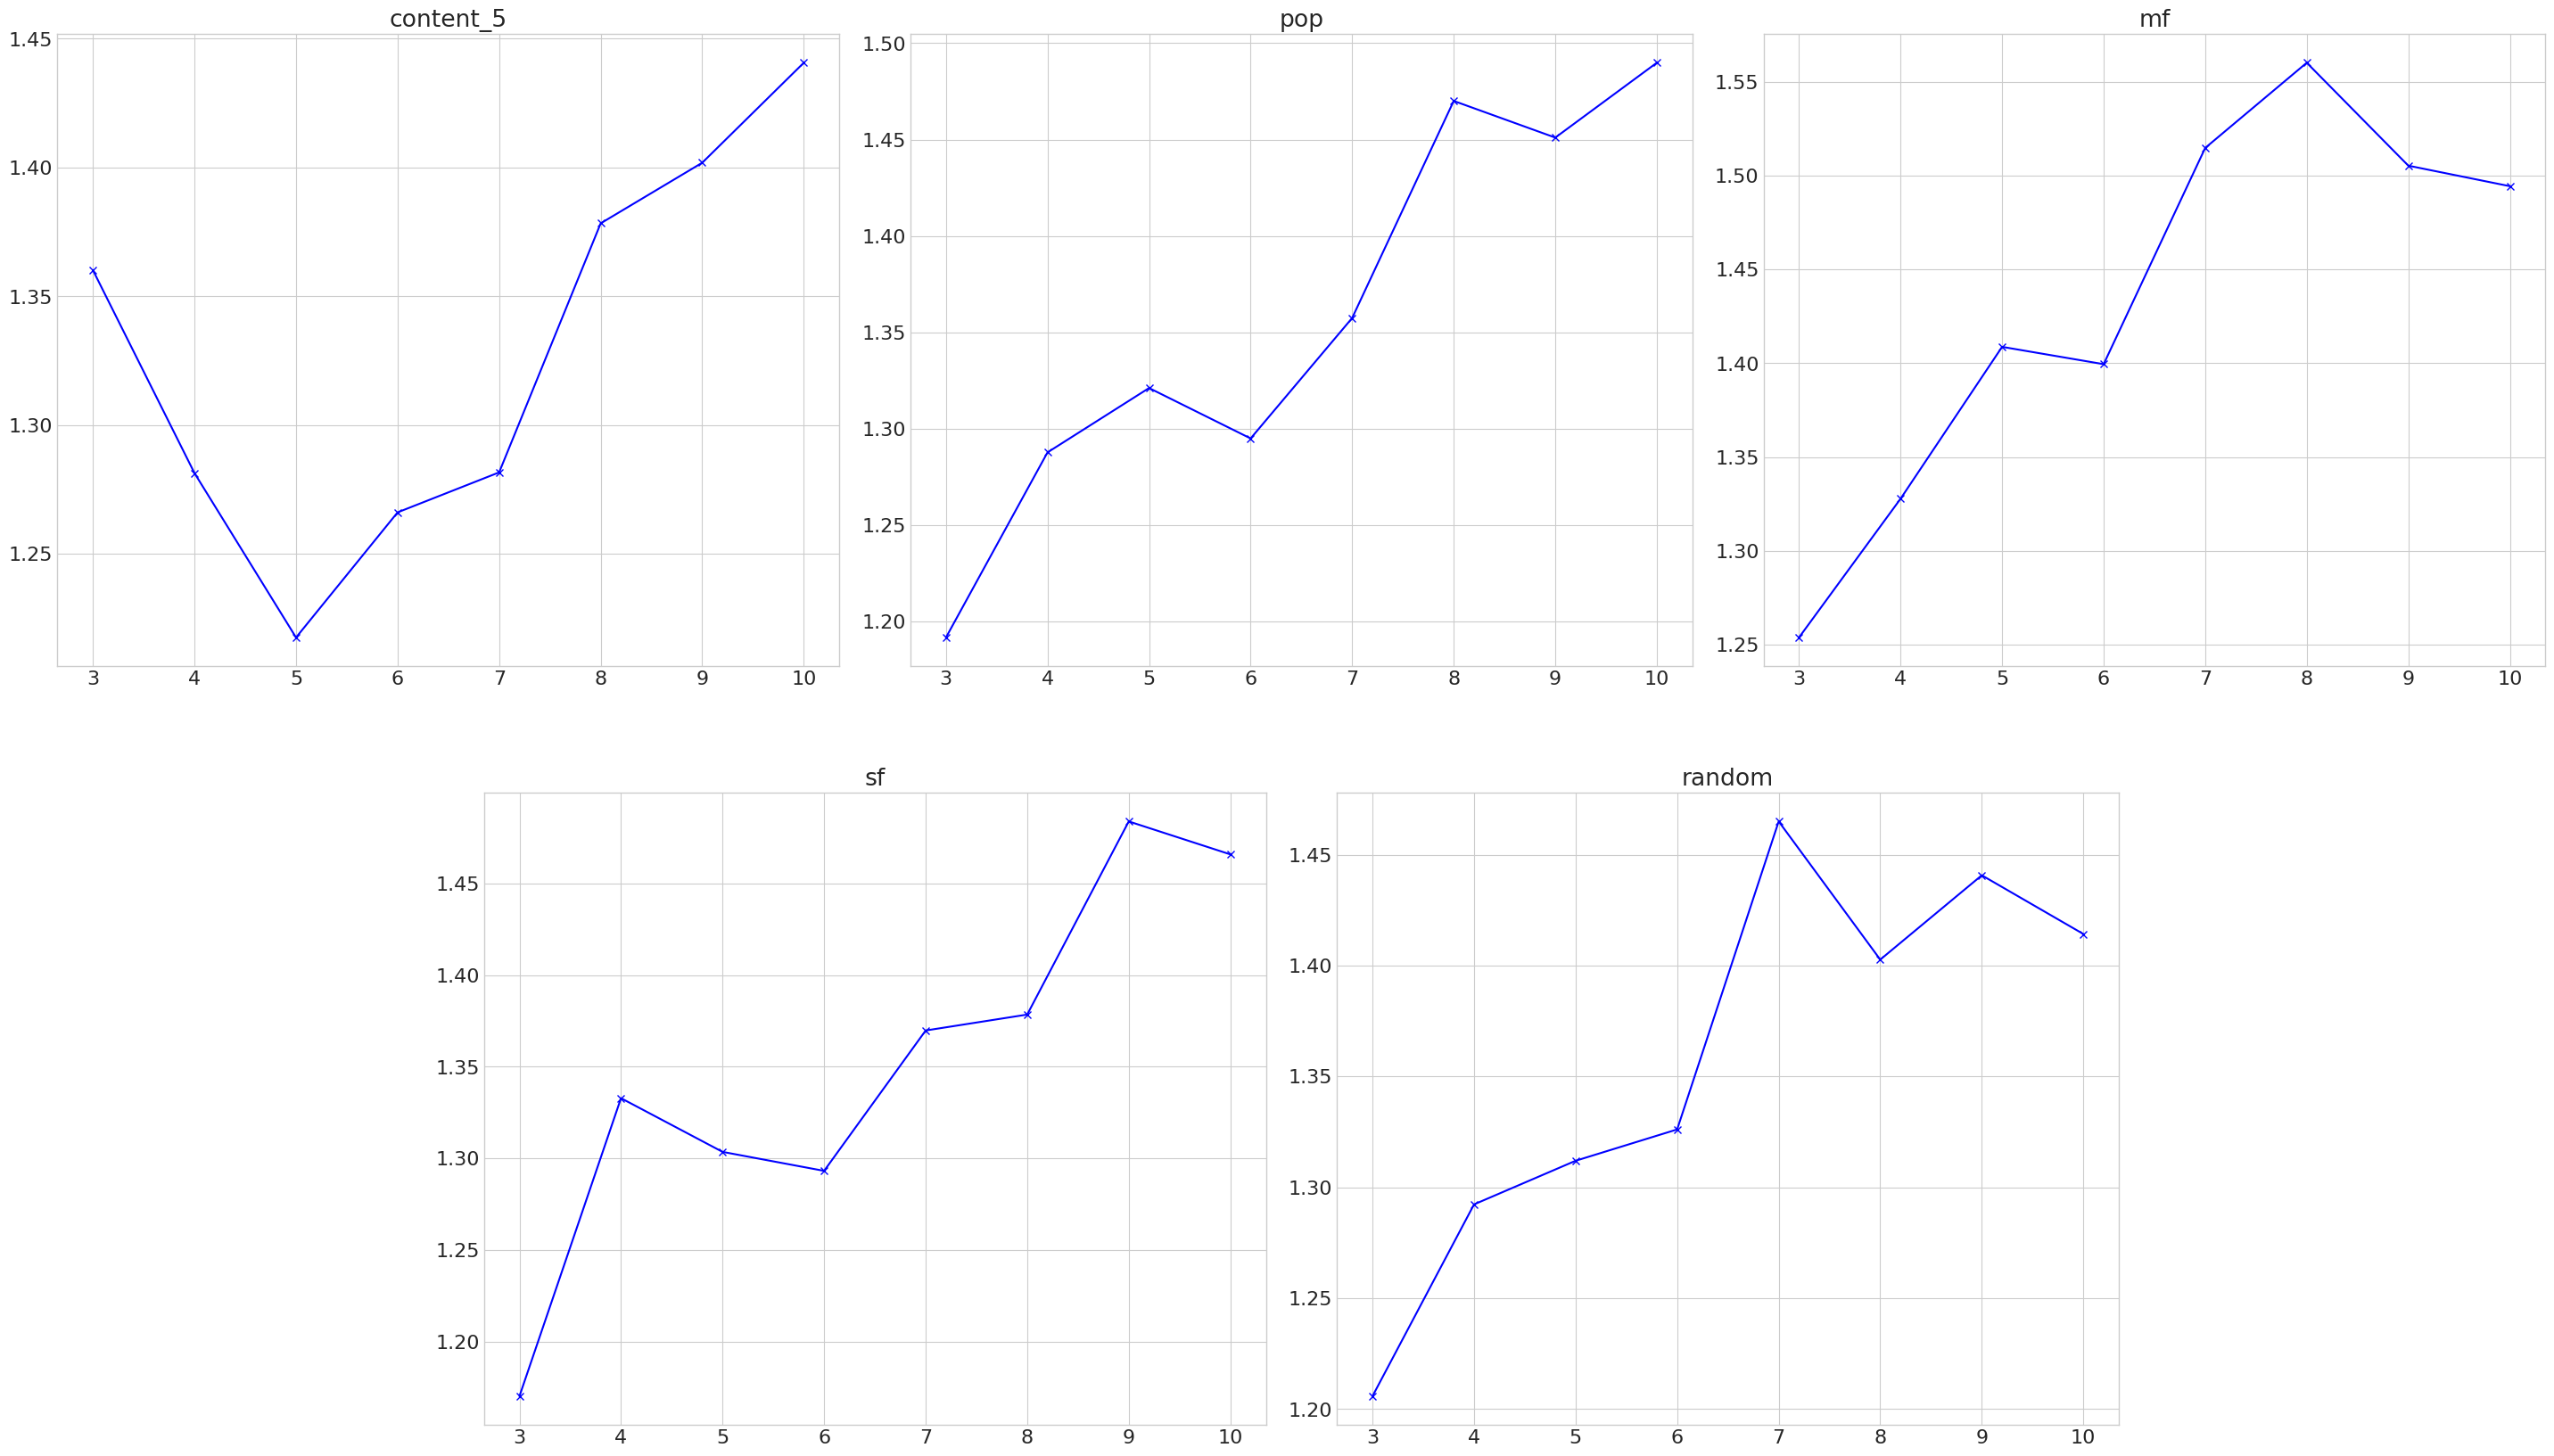

In [45]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(36, 20)) # 36 width x 20 height
fig.subplots_adjust(hspace=0.2, wspace=0.2, bottom=0.1)
gs = gridspec.GridSpec(2, 6)

off_model_keys = [model_keys[1]] + model_keys[3:]
axes = []
axes.append(gs[0,0:2])
axes.append(gs[0,2:4])
axes.append(gs[0,4:6])
axes.append(gs[1,1:3])
axes.append(gs[1,3:5])

upper_ylim = -10.0
lower_ylim = 10.0
col = -1
iter_index = -1
tot_utils = dict()
opt_k = dict()

for mo in off_model_keys:
    col+=1

    data = traits[mo][:,:,iter_index,:].reshape((-1,7))[:,:-1]
    opt_db = 1000
    db = []
    kmax = 10

    # dissimilarity would not be defined for a single cluster, thus, minimum number of clusters should be 2
    for k in range(3, kmax+1):
        kmeans = KMeans(n_clusters = k, random_state=1234).fit(data)
        labels = kmeans.labels_
        db.append(davies_bouldin_score(data, labels))
        if  opt_db > db[-1]:
            opt_db = db[-1]
            opt_k[mo] = k
    ax = plt.subplot(axes[col])
    ax.plot(range(3, kmax+1), db, 'bx-')
    ax.set_title(mo)

fig.show()

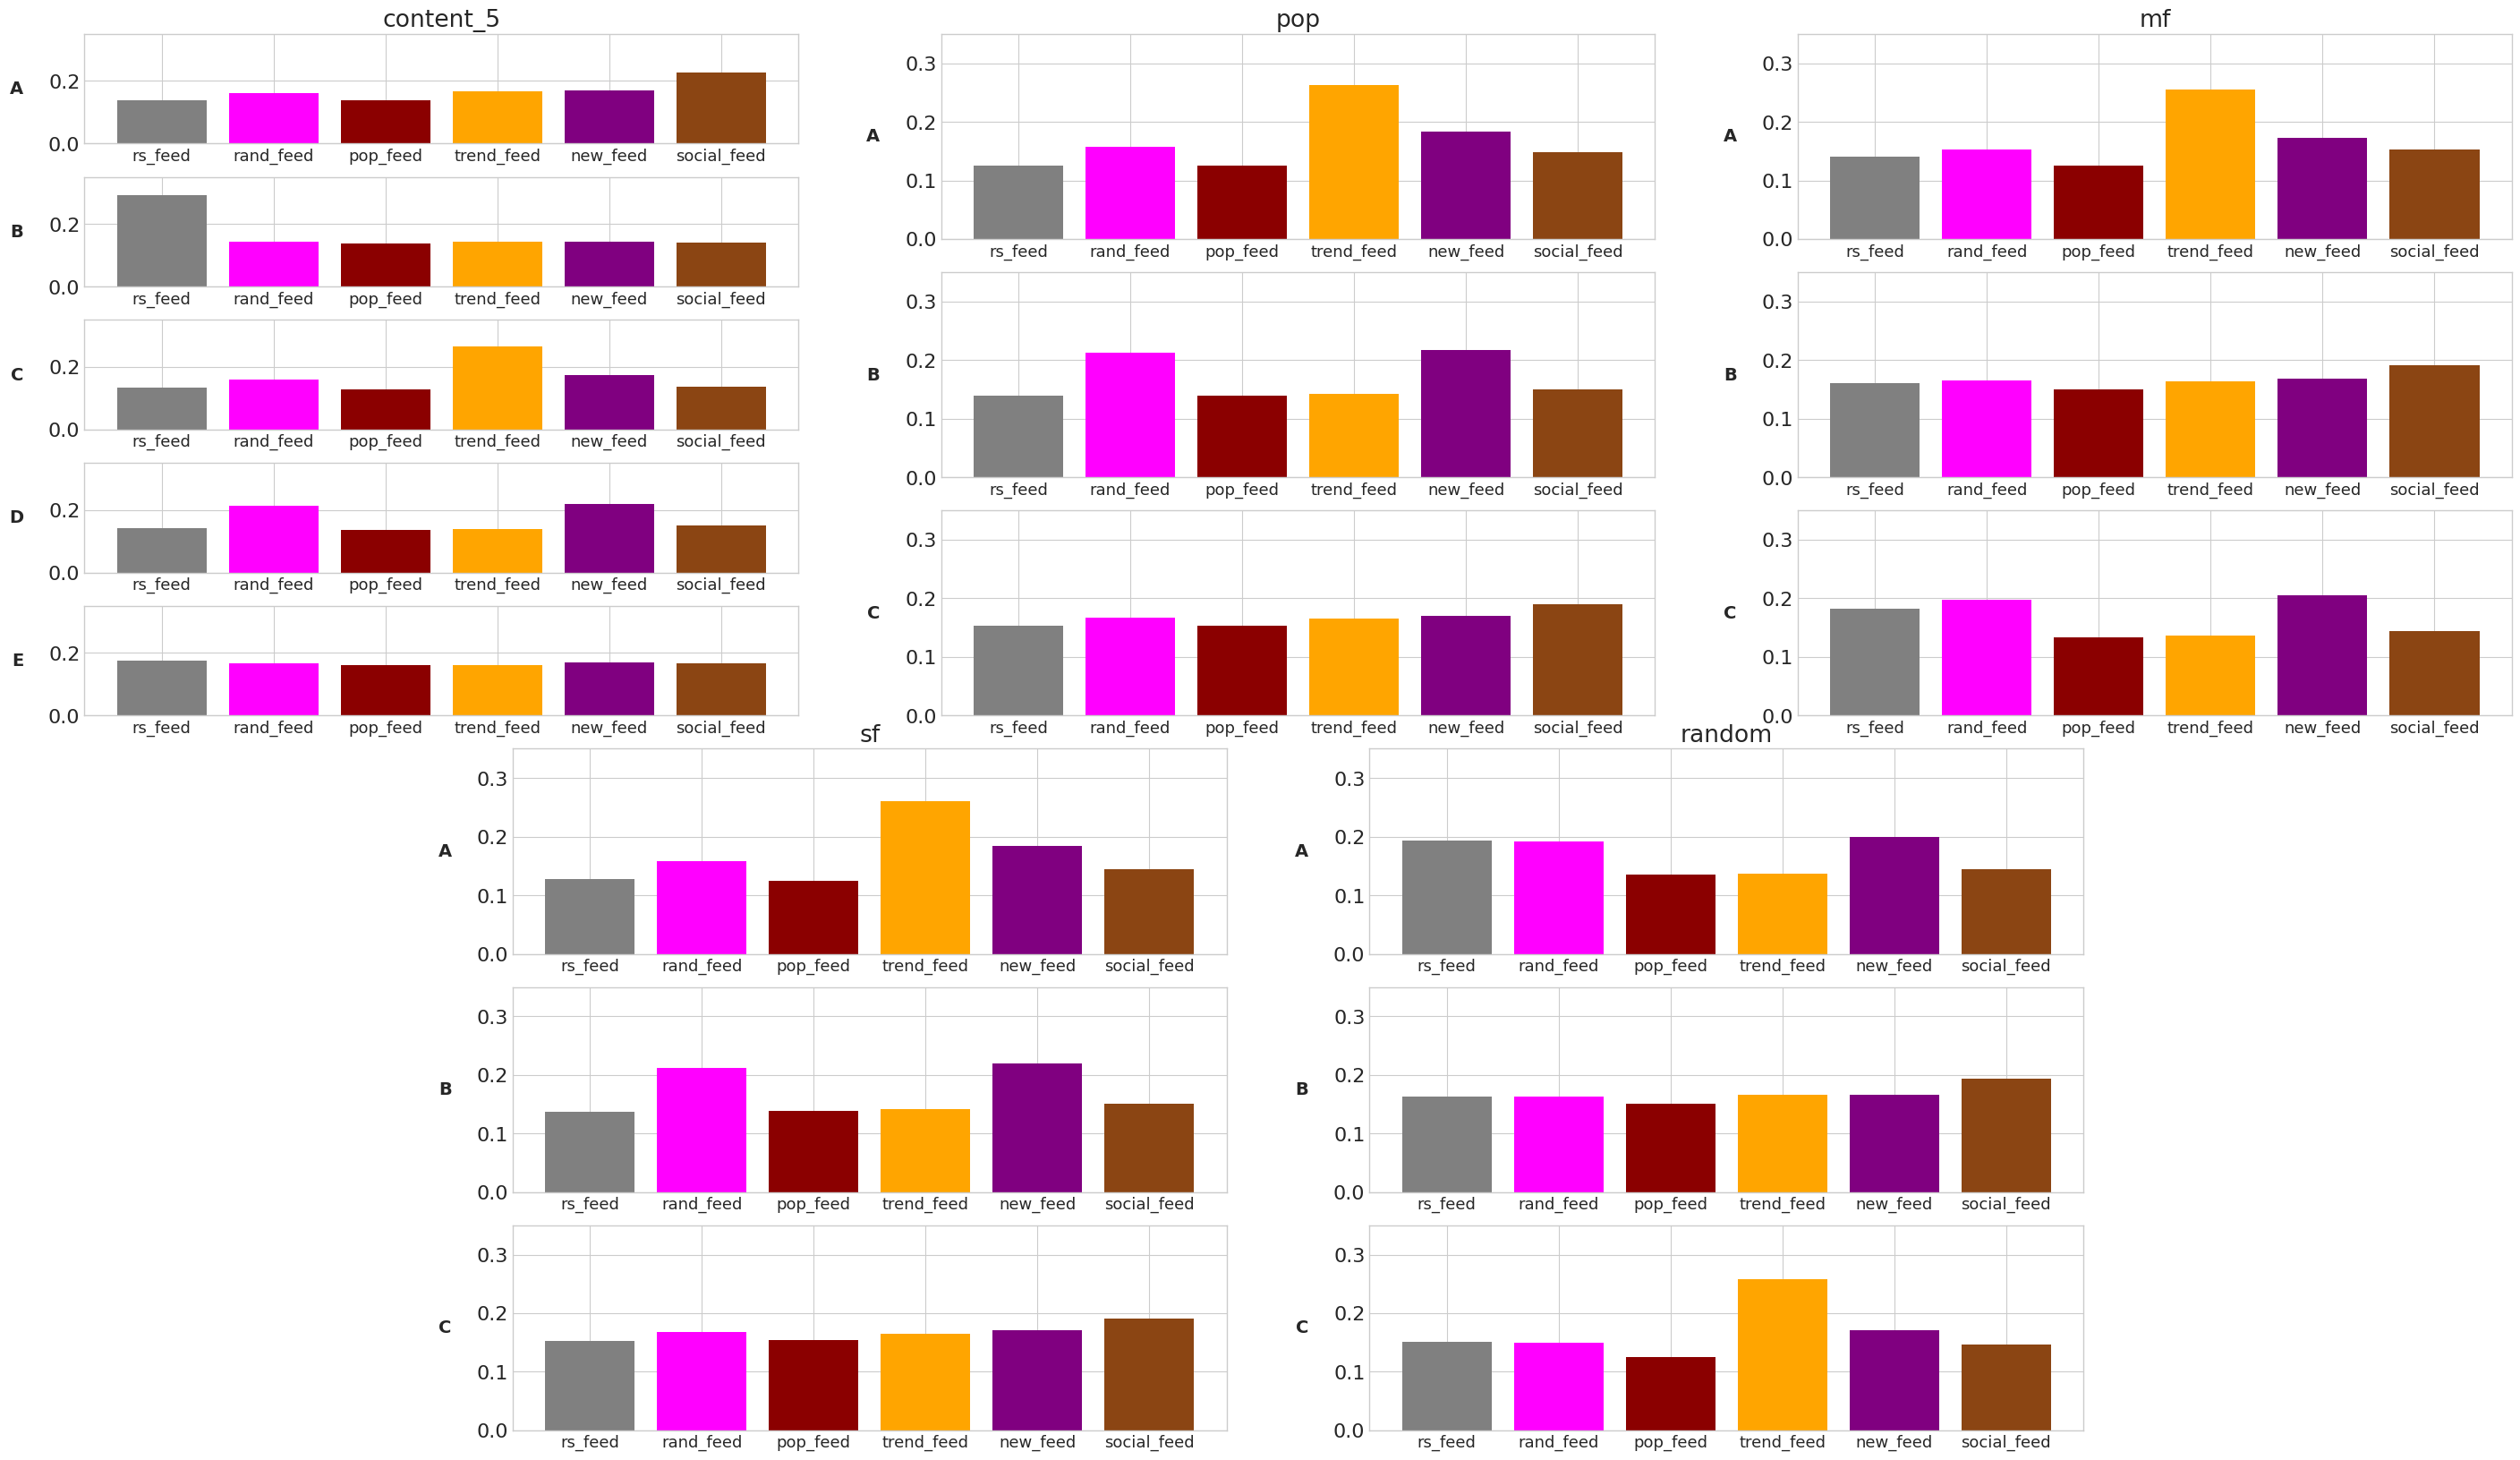

In [51]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(35, 20))
fig.subplots_adjust(hspace=2.3, wspace=0.5, bottom=0.1)
gs = gridspec.GridSpec(30, 6)

axes_indices = []
axes_indices.append([0,0])
axes_indices.append([0,2])
axes_indices.append([0,4])
axes_indices.append([15,1])
axes_indices.append([15,3])

col = -1
iter_index = -1
tot_utils = dict()
mo_labels = dict()
cluster_names = dict()

for mo in off_model_keys:
    col+=1
    tot_utils[mo] = dict()
    tot_utils[mo]["base"] = [base_utilities[mo].mean(), base_utilities[mo].std()]
    tot_utils[mo]["dynamic"] = [utilities[mo].mean(), utilities[mo].std()]

    data = traits[mo][:,:,iter_index,:].reshape((-1,7))[:,:-1]

    kmeans = KMeans(n_clusters = opt_k[mo], random_state=1234).fit(data)
    mo_labels[mo] = kmeans.labels_
    cluster_data = np.array([data[[mo_labels[mo][row] == h for row in range(data.shape[0])]].mean(axis=0) for h in range(opt_k[mo])])
    cluster_names[mo] = np.array([character for character in ['A','B','C','D','E'][:opt_k[mo]]])
    steps = int(15 / opt_k[mo]) # we already know the number of clusters of all RSs is 5 and 3
    ax = plt.subplot(gs[axes_indices[col][0]: axes_indices[col][0] + steps, axes_indices[col][1] : axes_indices[col][1] + 2])
    ax.set_title(mo)
    flatten_utils = utilities[mo].mean(axis=2).flatten()
    for k in range(opt_k[mo]):
        tot_utils[mo][cluster_names[mo][k]] = [flatten_utils[[mo_labels[mo] == k]].mean(), flatten_utils[[mo_labels[mo] == k]].std()]
        ax = plt.subplot(gs[axes_indices[col][0] + (k*steps) : axes_indices[col][0] + ((k+1)*steps), axes_indices[col][1] : axes_indices[col][1] + 2])
        ax.bar(feed_names, cluster_data[k], color = indexable_feed_colors)
        ax.set_ylim(0, 0.35)
        ax.set_ylabel(cluster_names[mo][k], rotation=0, ha='right', va='center', fontsize=14, labelpad=20, fontweight='bold')
        ax.tick_params(axis='x', labelsize=13)

fig.show()

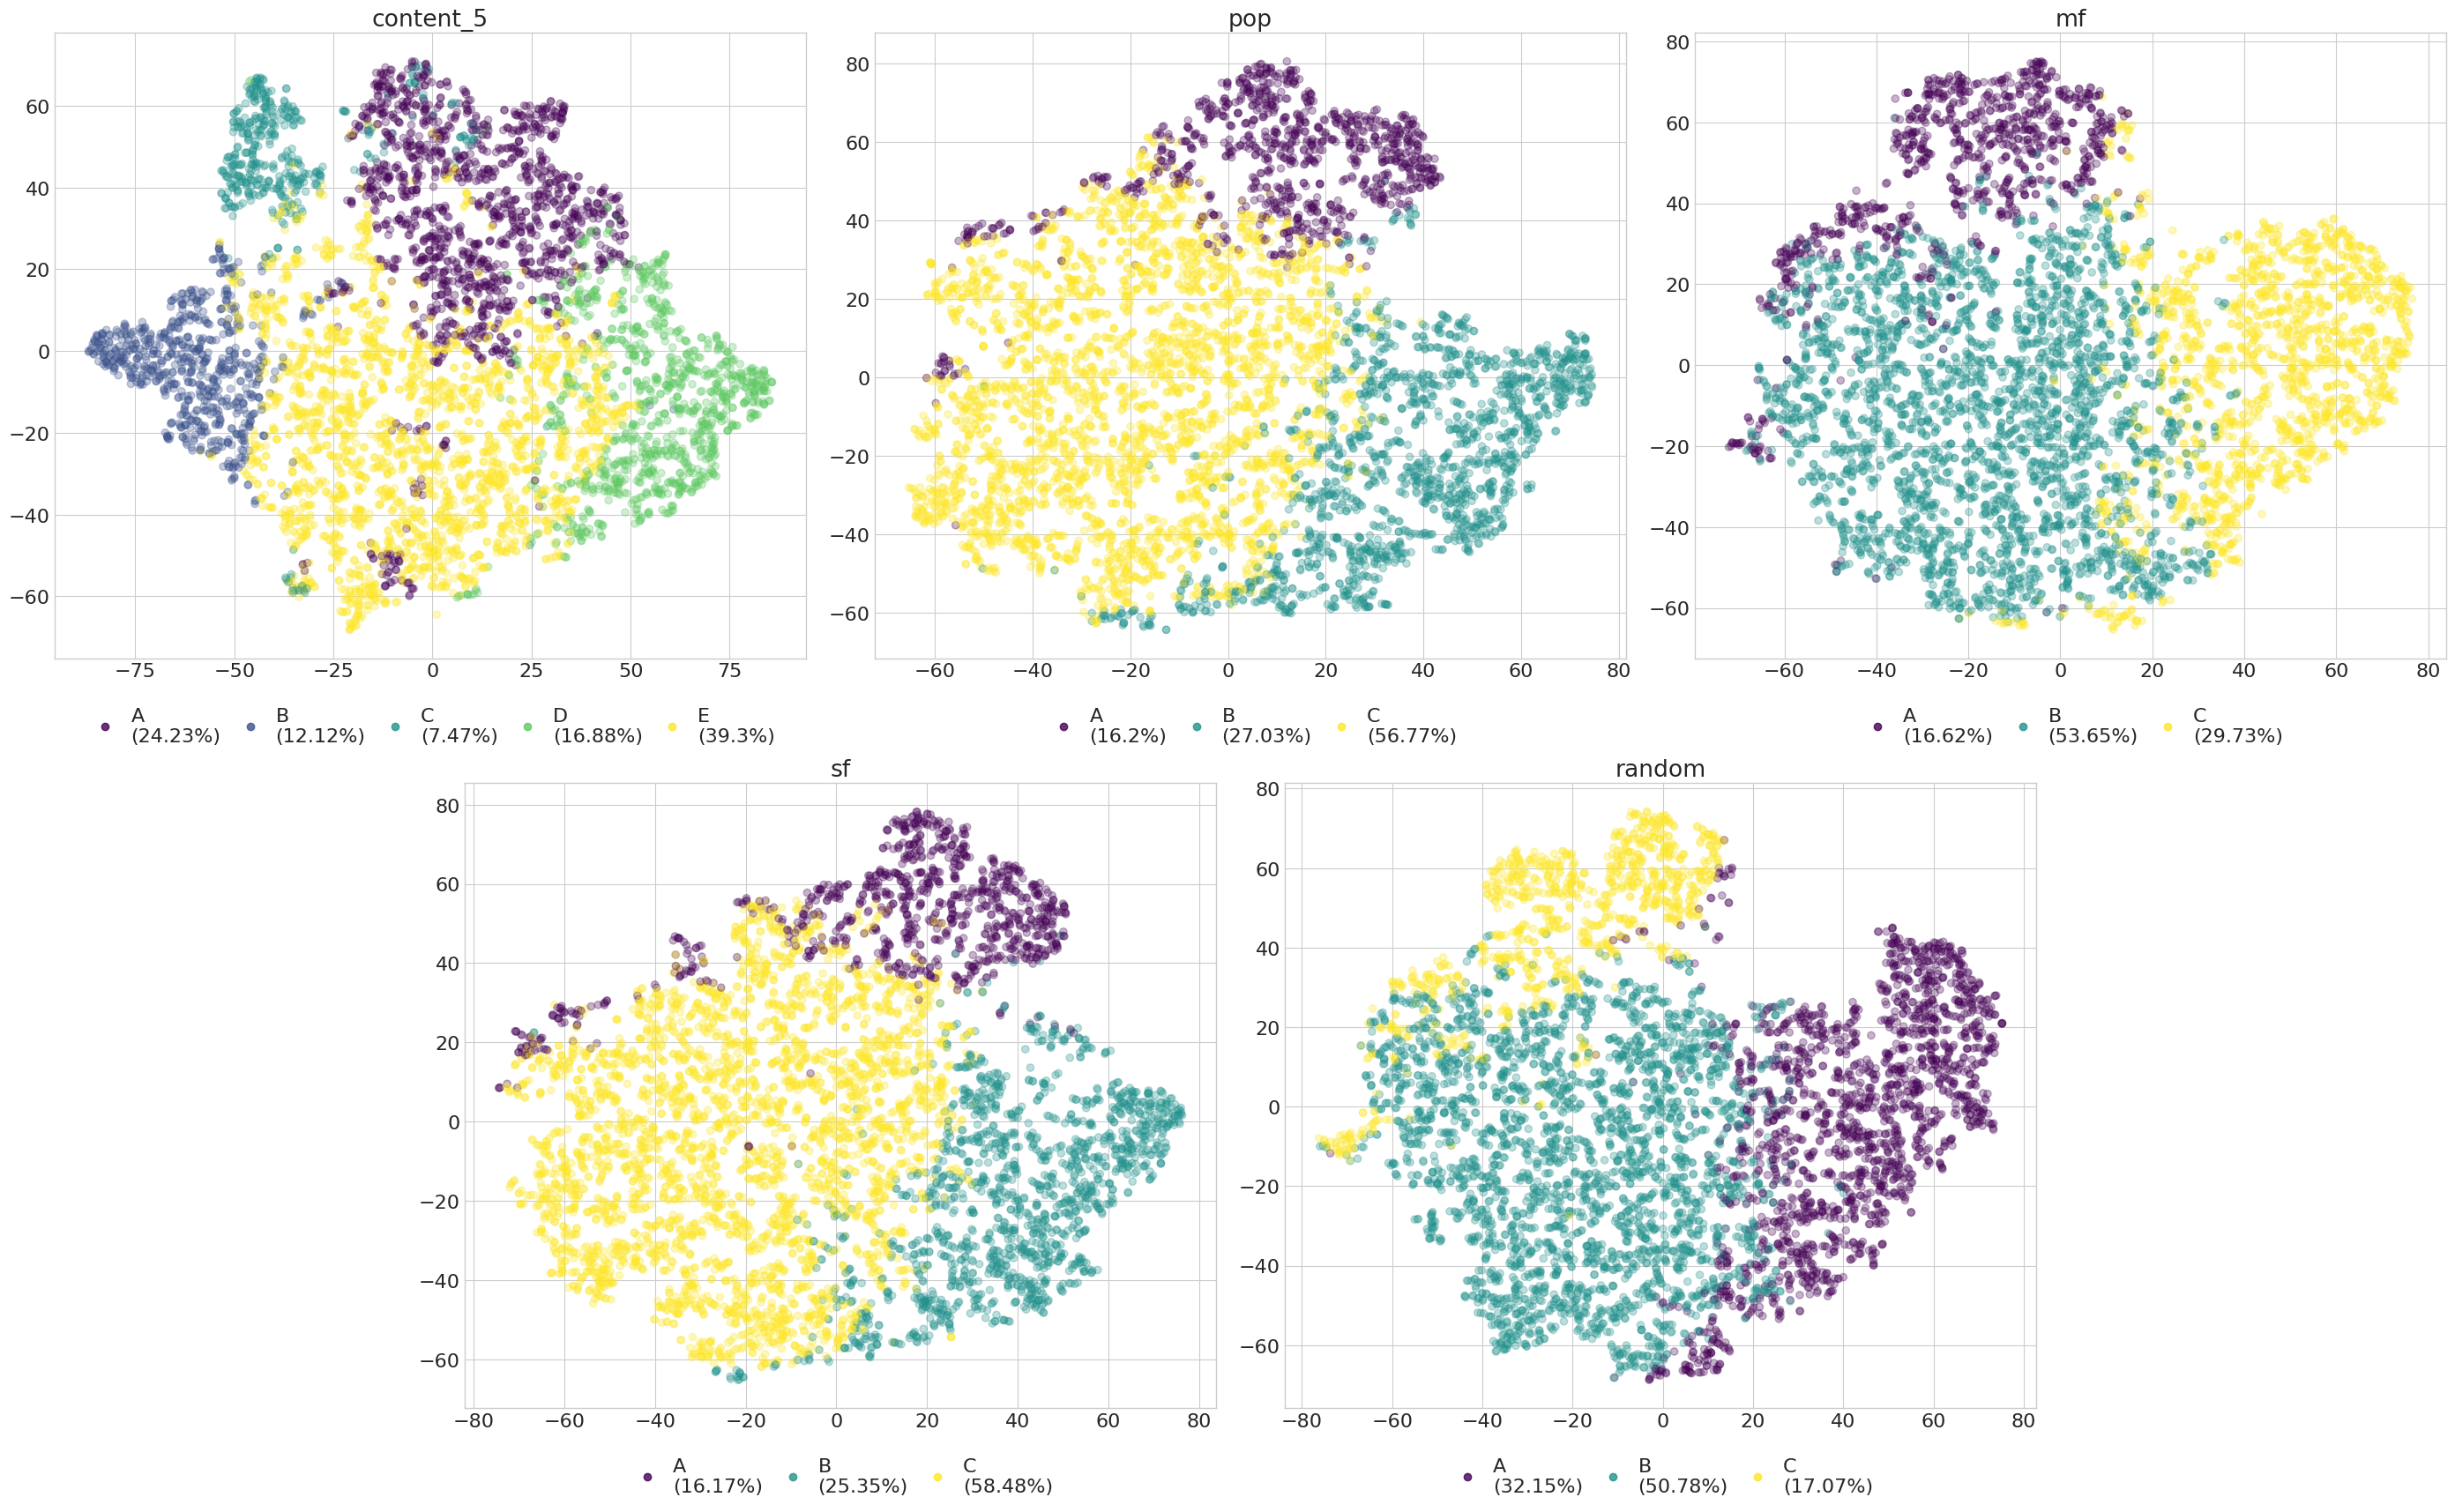

In [44]:
plt.rcParams.update({'font.size': 16})
fig = plt.figure(figsize=(35, 20))
fig.subplots_adjust(hspace=0.2, wspace=0.2, bottom=0.1)
gs = gridspec.GridSpec(2, 6)

axes = []
axes.append(gs[0,0:2])
axes.append(gs[0,2:4])
axes.append(gs[0,4:6])
axes.append(gs[1,1:3])
axes.append(gs[1,3:5])

col = -1
iter_index = -1

for mo in off_model_keys:
    col+=1
    
    data = traits[mo][:,:,iter_index,:].reshape((-1,7))[:,:-1]
    
    ax = plt.subplot(axes[col])
    X_scaled = scaler.fit_transform(data)
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=mo_labels[mo], cmap='viridis', alpha=0.3)
    s_handles, _ = scatter.legend_elements(prop="colors", alpha=0.8)
    s_labels = [cluster_names[mo][cn] + "\n(" + str(np.round((mo_labels[mo][mo_labels[mo] == cn].shape[0] / mo_labels[mo].shape[0])*100, 2)) +"%)"
                for cn in range(cluster_names[mo].shape[0])]
    legend = ax.legend(s_handles,
                       s_labels,
                       loc="upper center",
                       bbox_to_anchor=(0.5, -0.05),
                       fancybox=True,
                       shadow=True,
                       ncol=opt_k[mo],
                       columnspacing=0.5,
                       handletextpad=0.3)
    ax.set_title(mo)
fig.show()

In [52]:
tot_utils

{'content_5': {'base': [0.17537820549381794, 0.12016676940513378],
  'dynamic': [0.2444132606636285, 0.1087592014777095],
  'A': [0.25601565529874454, 0.06630668146045694],
  'B': [0.35018383685077165, 0.08240610159885728],
  'C': [0.3617705297112625, 0.09445897785121012],
  'D': [0.22740474539938416, 0.06193392673007253],
  'E': [0.1896585866779746, 0.03814086314036443]},
 'pop': {'base': [0.1720021095675764, 0.12034364936892877],
  'dynamic': [0.23253212234587753, 0.11022110162234465],
  'A': [0.35549464789736457, 0.08395198293206732],
  'B': [0.22320256510546188, 0.06069010644724088],
  'C': [0.20188413849617365, 0.05033723764084955]},
 'mf': {'base': [0.16701634338285992, 0.11193958867314213],
  'dynamic': [0.23524270602352368, 0.10928601054622238],
  'A': [0.3513555607763889, 0.08544001558191056],
  'B': [0.20673919924468953, 0.05028561874432231],
  'C': [0.22178321730853537, 0.06528489844190051]},
 'sf': {'base': [0.18327543257141368, 0.11884311002662859],
  'dynamic': [0.2322634